Processing: 20260224_000000_n.mkv
  Start time (from filename): 2026-02-24 00:00:00
  V/div: 2.0, FPS: 20.0
  Grid height (STORED): 23.296 px -> 0.085853 V/px
  Grid height (INJ): 28.417 px -> 0.070380 V/px
  Red pixel count threshold (STORED): 1000
  Red pixel count threshold (INJ): 1000
  Split pixel inj_time_px (absolute): 30
  Method: split red mask in x, profile+threshold width per part
  Frames extracted: 6000
  Vpp_stored range: 0.859 - 3.778 V
  Vpp_inj range: 1.267 - 4.152 V
  Duration: 299.95 s


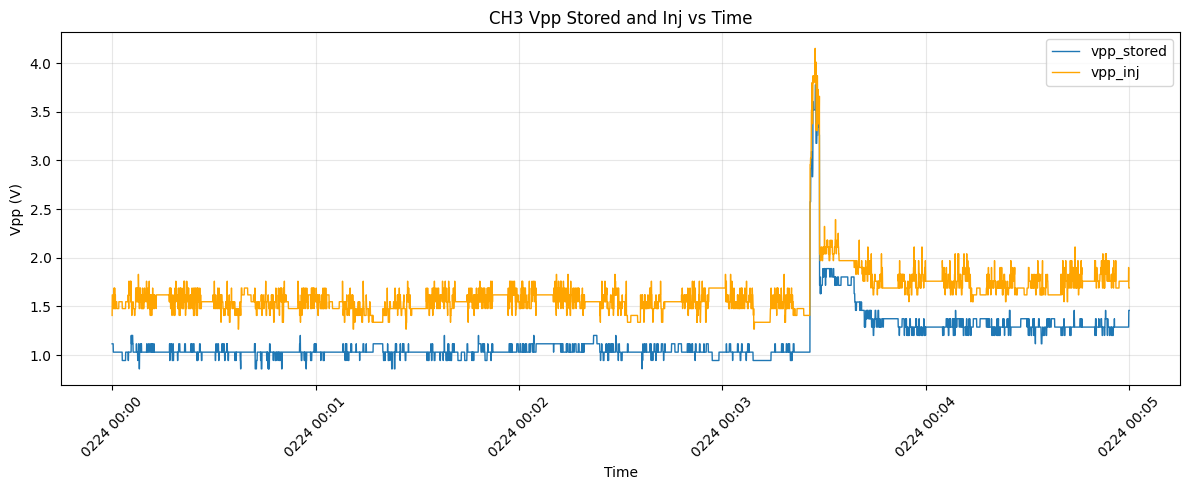

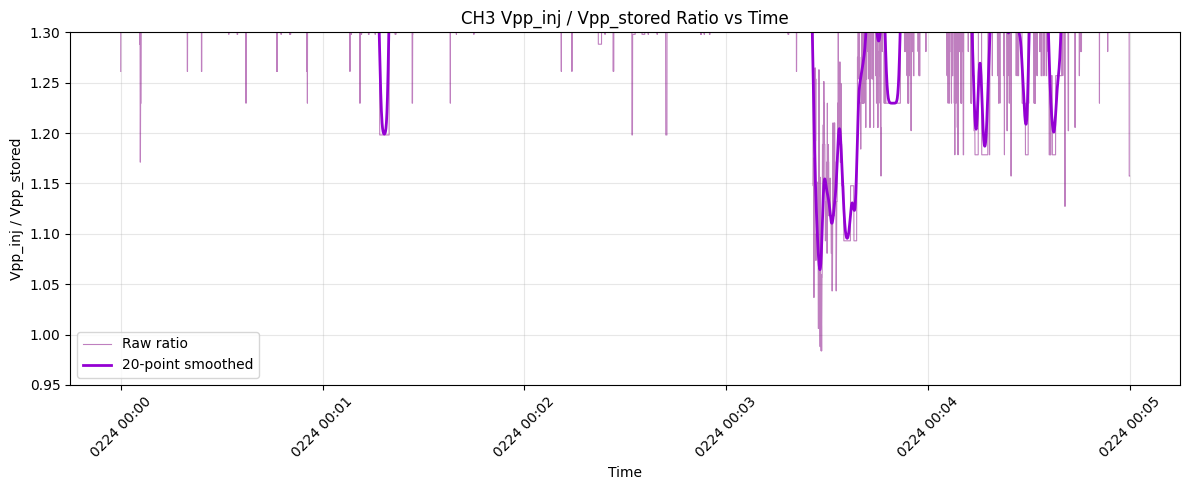

In [52]:
# Cell 1 and 2 are for testing.
# Cell 3: batch process one single date
# Another notebook "_batch" is used for batch processing all dates.

import math
import os
import re
import cv2
import numpy as np
from datetime import datetime, timedelta
from scipy.signal import find_peaks, peak_widths
from scipy.ndimage import gaussian_filter1d

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Parameters (CHANGE)
test_file = "/Volumes/D06V1/D06V1/OSC_Videos/2026ab/20260224/20260224_000000_n.mkv"
# test_file = "/Volumes/D06V1/D06V1/OSC_Videos/2026ab/20260127/RecData/0014/20260127_001000_n.mkv"
# test_file = "/Volumes/D06V1/D06V1/OSC_Videos/2026ab/20260203/RecData/0014/20260203_201500_n.mkv"
# test_file = "/Volumes/D06V1/D06V1/OSC_Videos/2026ab/20260209/RecData/0014/20260209_062000_n.mkv"
peak_threshold = 3.5  # V, for peak detection in Vpp signal
profile_threshold_stored = 1000  # pixel count threshold for stored region
profile_threshold_inj = 1000     # pixel count threshold for inj region

# Parameters (DO NOT CHANGE)
grid_height_px_stored = 3.4/5.56*400/10/1.05  # for one grid corresponding to 2 V (stored region, distorted).
grid_height_px_inj = 3.95/5.56*400/10     # for one grid corresponding to 2 V (inj region)
# inj_time_px = math.floor(0.56/7.25*500)   # absolute split pixel number
inj_time_px = 30
v_div = 2.0
fps = 20.0

def extract_datetime_from_filename(filename):
    match = re.search(r"(\d{8})_(\d{6})", filename)
    if not match:
        return None
    date_part, time_part = match.groups()
    return datetime.strptime(date_part + time_part, "%Y%m%d%H%M%S")

def _vpp_from_mask(mask_part, threshold, volts_per_pixel):
    vertical_profile = np.sum(mask_part, axis=1)
    smooth_profile = gaussian_filter1d(vertical_profile.astype(float), sigma=2.0)
    above_threshold = smooth_profile > threshold
    if np.any(above_threshold):
        threshold_positions = np.where(above_threshold)[0]
        y_min = threshold_positions[0]
        y_max = threshold_positions[-1]
        peak_width_pixels = y_max - y_min
        return peak_width_pixels * volts_per_pixel
    return np.nan

def compute_vpp_series_for_file(file_path, v_div=2.0, fps=20.0, threshold_stored=1000, threshold_inj=1000, split_x=None, grid_height_px_stored=3.4/5.56*400/10/1.05, grid_height_px_inj=3.95/5.56*400/10):
    cap = cv2.VideoCapture(file_path)
    volts_per_pixel_stored = v_div / grid_height_px_stored
    volts_per_pixel_inj = v_div / grid_height_px_inj

    vpp_stored_series = []
    vpp_inj_series = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        height, width, _ = frame.shape
        roi = frame[int(height * 0.2):int(height * 0.8), int(width * 0.1):int(width * 0.9)]

        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

        mask1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
        mask2 = cv2.inRange(hsv, np.array([160, 100, 100]), np.array([180, 255, 255]))
        red_mask = cv2.bitwise_or(mask1, mask2)

        split_idx = max(0, min(int(split_x), red_mask.shape[1] - 1))

        # Part 1: x <= inj_time_px (STORED)
        red_mask_stored = red_mask[:, :split_idx + 1]
        # Part 2: x > inj_time_px (INJ)
        red_mask_inj = red_mask[:, split_idx + 1:]

        if red_mask_stored.shape[1] > 0:
            vpp_stored_series.append(_vpp_from_mask(red_mask_stored, threshold_stored, volts_per_pixel_stored))
        else:
            vpp_stored_series.append(np.nan)

        if red_mask_inj.shape[1] > 0:
            vpp_inj_series.append(_vpp_from_mask(red_mask_inj, threshold_inj, volts_per_pixel_inj))
        else:
            vpp_inj_series.append(np.nan)

    cap.release()

    time_series_sec = np.arange(len(vpp_stored_series)) / fps
    return time_series_sec, np.array(vpp_stored_series), np.array(vpp_inj_series)

# Extract start time from filename
file_path = test_file
basename = os.path.basename(file_path)
start_dt = extract_datetime_from_filename(basename)

if start_dt is None:
    raise ValueError(f"Could not extract datetime from filename: {basename}")

print(f"Processing: {basename}")
print(f"  Start time (from filename): {start_dt.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  V/div: {v_div}, FPS: {fps}")
print(f"  Grid height (STORED): {grid_height_px_stored:.3f} px -> {v_div/grid_height_px_stored:.6f} V/px")
print(f"  Grid height (INJ): {grid_height_px_inj:.3f} px -> {v_div/grid_height_px_inj:.6f} V/px")
print(f"  Red pixel count threshold (STORED): {profile_threshold_stored}")
print(f"  Red pixel count threshold (INJ): {profile_threshold_inj}")
print(f"  Split pixel inj_time_px (absolute): {inj_time_px}")
print("  Method: split red mask in x, profile+threshold width per part")

time_s, vpp_stored, vpp_inj = compute_vpp_series_for_file(
    file_path,
    v_div=v_div,
    fps=fps,
    threshold_stored=profile_threshold_stored,
    threshold_inj=profile_threshold_inj,
    split_x=inj_time_px,
    grid_height_px_stored=grid_height_px_stored,
    grid_height_px_inj=grid_height_px_inj,
)

print(f"  Frames extracted: {len(vpp_stored)}")
print(f"  Vpp_stored range: {np.nanmin(vpp_stored):.3f} - {np.nanmax(vpp_stored):.3f} V")
print(f"  Vpp_inj range: {np.nanmin(vpp_inj):.3f} - {np.nanmax(vpp_inj):.3f} V")
print(f"  Duration: {time_s[-1]:.2f} s")

time_datetime = np.array([start_dt + timedelta(seconds=t) for t in time_s])

# First plot: Vpp vs time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time_datetime, vpp_stored, linewidth=1, label="vpp_stored")
ax.plot(time_datetime, vpp_inj, linewidth=1, color="orange", label="vpp_inj")
ax.set_title("CH3 Vpp Stored and Inj vs Time")
ax.set_xlabel("Time")
ax.set_ylabel("Vpp (V)")
ax.grid(True, alpha=0.3)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Second plot: Vpp_inj / Vpp_stored ratio with 20-point local averaging
ratio = vpp_inj / vpp_stored
ratio_smoothed = gaussian_filter1d(ratio, sigma=10)  # 20-point local averaging

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time_datetime, ratio, linewidth=0.8, color="purple", alpha=0.5, label="Raw ratio")
ax.plot(time_datetime, ratio_smoothed, linewidth=2, color="darkviolet", label="20-point smoothed")
ax.set_title("CH3 Vpp_inj / Vpp_stored Ratio vs Time")
ax.set_xlabel("Time")
ax.set_ylabel("Vpp_inj / Vpp_stored")
ax.grid(True, alpha=0.3)
ax.set_ylim(0.95, 1.3)  # Set y-axis limits for better visualization of ratio changes
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Found 1 STORED peak(s) with Vpp_stored > 3.5 V
Found 2 INJ peak(s) with Vpp_inj > 3.5 V

STORED PEAKS (x <= inj_time_px)

Stored Peak 1:
  Frame: 4149
  Time: 2026-02-24 00:03:27.450
  Vpp_STORED: 3.7775 V  (triggered peak)
  Vpp_INJ:    3.8005 V  (simultaneous)
  Detected bounds (stored region): [133, 177]
  Width: 44.0 px -> 3.7775 V


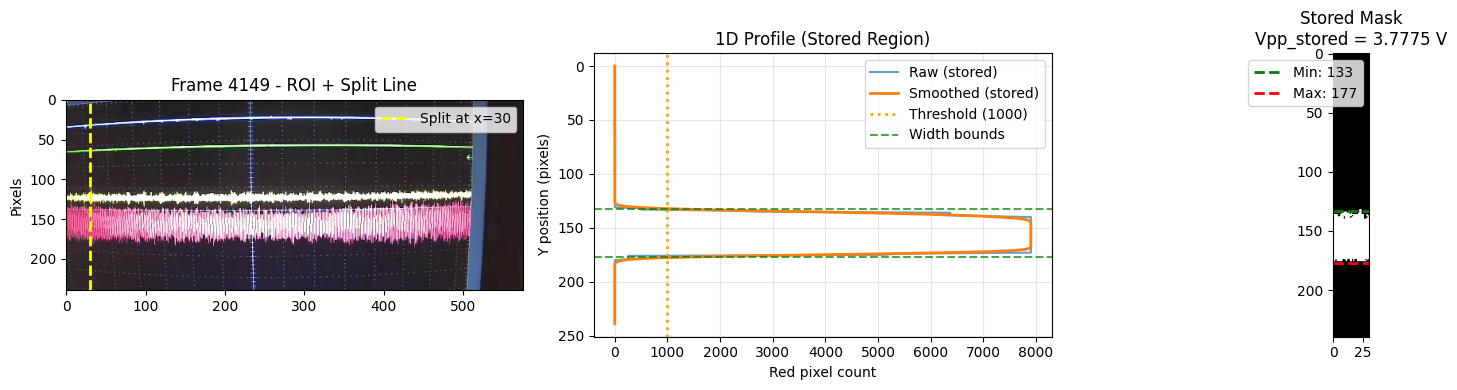


INJ PEAKS (x > inj_time_px)

Inj Peak 1:
  Frame: 4147
  Time: 2026-02-24 00:03:27.350
  Vpp_STORED:  3.6058 V  (simultaneous)
  Vpp_INJ:     4.1524 V  (triggered peak)
  Detected bounds (inj region): [128, 187]
  Width: 59.0 px -> 4.1524 V

Inj Peak 2:
  Frame: 4172
  Time: 2026-02-24 00:03:28.600
  Vpp_STORED:  3.2624 V  (simultaneous)
  Vpp_INJ:     3.6597 V  (triggered peak)
  Detected bounds (inj region): [132, 184]
  Width: 52.0 px -> 3.6597 V


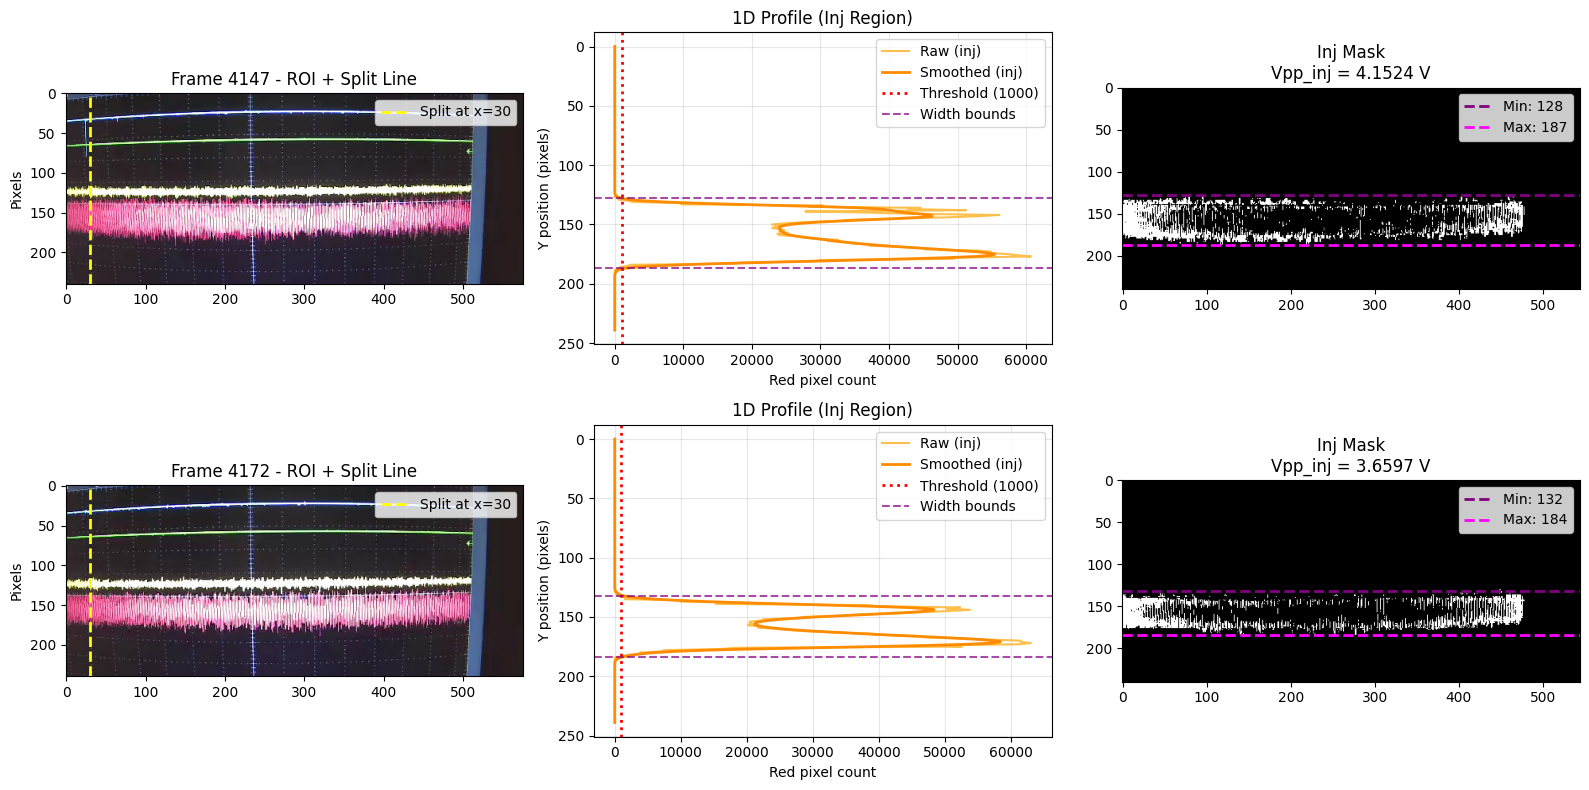


SUMMARY
Stored peaks: 1
  1. Frame 4149: vpp_stored=3.7775V, vpp_inj=3.8005V

Inj peaks: 2
  1. Frame 4147: vpp_stored=3.6058V, vpp_inj=4.1524V
  2. Frame 4172: vpp_stored=3.2624V, vpp_inj=3.6597V


In [53]:
# Automatic peak finder with visualization
# Detects peaks in BOTH Vpp_stored and Vpp_inj signals
# Shows 3-panel visualization for each region separately
# Uses separate thresholds: 1000 for stored, 2000 for inj
# Uses separate grid heights for stored and inj regions

# Find peaks in both signals

vpp_peaks_stored, _ = find_peaks(vpp_stored, height=peak_threshold, distance=20)
vpp_peaks_inj, _ = find_peaks(vpp_inj, height=peak_threshold, distance=20)

print(f"\nFound {len(vpp_peaks_stored)} STORED peak(s) with Vpp_stored > {peak_threshold} V")
print(f"Found {len(vpp_peaks_inj)} INJ peak(s) with Vpp_inj > {peak_threshold} V")
print("="*60)

cap = cv2.VideoCapture(test_file)
volts_per_pixel_stored = v_div / grid_height_px_stored
volts_per_pixel_inj = v_div / grid_height_px_inj

# ===== STORED PEAKS =====
if len(vpp_peaks_stored) > 0:
    print("\n" + "="*60)
    print("STORED PEAKS (x <= inj_time_px)")
    print("="*60)
    
    num_peaks = len(vpp_peaks_stored)
    fig, axes = plt.subplots(num_peaks, 3, figsize=(16, 4 * num_peaks))
    if num_peaks == 1:
        axes = axes.reshape(1, -1)
    
    for peak_idx, frame_num in enumerate(vpp_peaks_stored):
        vpp_stored_value = vpp_stored[frame_num]
        vpp_inj_value = vpp_inj[frame_num]
        peak_time = time_datetime[frame_num]
        
        print(f"\nStored Peak {peak_idx + 1}:")
        print(f"  Frame: {frame_num}")
        print(f"  Time: {peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]}")
        print(f"  Vpp_STORED: {vpp_stored_value:.4f} V  (triggered peak)")
        print(f"  Vpp_INJ:    {vpp_inj_value:.4f} V  (simultaneous)")
        
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        if not ret:
            continue

        height, width, _ = frame.shape
        roi = frame[int(height * 0.2):int(height * 0.8), int(width * 0.1):int(width * 0.9)]
        roi_height = roi.shape[0]

        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
        mask1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
        mask2 = cv2.inRange(hsv, np.array([160, 100, 100]), np.array([180, 255, 255]))
        red_mask = cv2.bitwise_or(mask1, mask2)

        # Split the mask
        split_idx = max(0, min(int(inj_time_px), red_mask.shape[1] - 1))
        red_mask_stored = red_mask[:, :split_idx + 1]

        # Create profile from stored region only (using profile_threshold_stored)
        vertical_profile = np.sum(red_mask_stored, axis=1)
        smooth_profile = gaussian_filter1d(vertical_profile.astype(float), sigma=2.0)
        above_threshold = smooth_profile > profile_threshold_stored
        
        if np.any(above_threshold):
            threshold_positions = np.where(above_threshold)[0]
            left_bound = threshold_positions[0]
            right_bound = threshold_positions[-1]
            peak_width_pixels = right_bound - left_bound
            vpp_from_profile = peak_width_pixels * volts_per_pixel_stored
            print(f"  Detected bounds (stored region): [{left_bound}, {right_bound}]")
            print(f"  Width: {peak_width_pixels:.1f} px -> {vpp_from_profile:.4f} V")
        else:
            left_bound, right_bound = 0, 0
        
        # Plot 1: ROI + full red mask
        roi_bgr = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
        axes[peak_idx, 0].imshow(roi_bgr)
        axes[peak_idx, 0].axvline(split_idx, color='yellow', linestyle='--', linewidth=2, label=f'Split at x={split_idx}')
        axes[peak_idx, 0].set_title(f"Frame {frame_num} - ROI + Split Line")
        axes[peak_idx, 0].set_ylabel("Pixels")
        axes[peak_idx, 0].legend()
        
        # Plot 2: 1D profile (stored region only)
        y_axis = np.arange(roi_height)
        axes[peak_idx, 1].plot(vertical_profile, y_axis, label='Raw (stored)', alpha=0.7)
        axes[peak_idx, 1].plot(smooth_profile, y_axis, label='Smoothed (stored)', linewidth=2)
        axes[peak_idx, 1].axvline(profile_threshold_stored, color='orange', linestyle=':', linewidth=2, label=f'Threshold ({profile_threshold_stored})')
        if np.any(above_threshold):
            axes[peak_idx, 1].axhline(left_bound, color='green', linestyle='--', alpha=0.7, label='Width bounds')
            axes[peak_idx, 1].axhline(right_bound, color='green', linestyle='--', alpha=0.7)
        axes[peak_idx, 1].set_xlabel('Red pixel count')
        axes[peak_idx, 1].set_ylabel('Y position (pixels)')
        axes[peak_idx, 1].legend()
        axes[peak_idx, 1].invert_yaxis()
        axes[peak_idx, 1].grid(True, alpha=0.3)
        axes[peak_idx, 1].set_title("1D Profile (Stored Region)")
        
        # Plot 3: Stored mask with bounds
        axes[peak_idx, 2].imshow(red_mask_stored, cmap='gray')
        if np.any(above_threshold):
            axes[peak_idx, 2].axhline(left_bound, color='green', linestyle='--', linewidth=2, label=f'Min: {left_bound}')
            axes[peak_idx, 2].axhline(right_bound, color='red', linestyle='--', linewidth=2, label=f'Max: {right_bound}')
        axes[peak_idx, 2].set_title(f"Stored Mask\nVpp_stored = {vpp_stored_value:.4f} V")
        axes[peak_idx, 2].legend()

    plt.tight_layout()
    plt.show()
else:
    print("No stored peaks found!")

# ===== INJ PEAKS =====
if len(vpp_peaks_inj) > 0:
    print("\n" + "="*60)
    print("INJ PEAKS (x > inj_time_px)")
    print("="*60)
    
    num_peaks = len(vpp_peaks_inj)
    fig, axes = plt.subplots(num_peaks, 3, figsize=(16, 4 * num_peaks))
    if num_peaks == 1:
        axes = axes.reshape(1, -1)
    
    for peak_idx, frame_num in enumerate(vpp_peaks_inj):
        vpp_stored_value = vpp_stored[frame_num]
        vpp_inj_value = vpp_inj[frame_num]
        peak_time = time_datetime[frame_num]
        
        print(f"\nInj Peak {peak_idx + 1}:")
        print(f"  Frame: {frame_num}")
        print(f"  Time: {peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]}")
        print(f"  Vpp_STORED:  {vpp_stored_value:.4f} V  (simultaneous)")
        print(f"  Vpp_INJ:     {vpp_inj_value:.4f} V  (triggered peak)")
        
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        if not ret:
            continue

        height, width, _ = frame.shape
        roi = frame[int(height * 0.2):int(height * 0.8), int(width * 0.1):int(width * 0.9)]
        roi_height = roi.shape[0]

        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
        mask1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
        mask2 = cv2.inRange(hsv, np.array([160, 100, 100]), np.array([180, 255, 255]))
        red_mask = cv2.bitwise_or(mask1, mask2)

        # Split the mask
        split_idx = max(0, min(int(inj_time_px), red_mask.shape[1] - 1))
        red_mask_inj = red_mask[:, split_idx + 1:]

        # Create profile from inj region only (using profile_threshold_inj)
        vertical_profile = np.sum(red_mask_inj, axis=1)
        smooth_profile = gaussian_filter1d(vertical_profile.astype(float), sigma=2.0)
        above_threshold = smooth_profile > profile_threshold_inj
        
        if np.any(above_threshold):
            threshold_positions = np.where(above_threshold)[0]
            left_bound = threshold_positions[0]
            right_bound = threshold_positions[-1]
            peak_width_pixels = right_bound - left_bound
            vpp_from_profile = peak_width_pixels * volts_per_pixel_inj
            print(f"  Detected bounds (inj region): [{left_bound}, {right_bound}]")
            print(f"  Width: {peak_width_pixels:.1f} px -> {vpp_from_profile:.4f} V")
        else:
            left_bound, right_bound = 0, 0
        
        # Plot 1: ROI + full red mask
        roi_bgr = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
        axes[peak_idx, 0].imshow(roi_bgr)
        axes[peak_idx, 0].axvline(split_idx, color='yellow', linestyle='--', linewidth=2, label=f'Split at x={split_idx}')
        axes[peak_idx, 0].set_title(f"Frame {frame_num} - ROI + Split Line")
        axes[peak_idx, 0].set_ylabel("Pixels")
        axes[peak_idx, 0].legend()
        
        # Plot 2: 1D profile (inj region only)
        y_axis = np.arange(roi_height)
        axes[peak_idx, 1].plot(vertical_profile, y_axis, color='orange', label='Raw (inj)', alpha=0.7)
        axes[peak_idx, 1].plot(smooth_profile, y_axis, color='darkorange', label='Smoothed (inj)', linewidth=2)
        axes[peak_idx, 1].axvline(profile_threshold_inj, color='red', linestyle=':', linewidth=2, label=f'Threshold ({profile_threshold_inj})')
        if np.any(above_threshold):
            axes[peak_idx, 1].axhline(left_bound, color='purple', linestyle='--', alpha=0.7, label='Width bounds')
            axes[peak_idx, 1].axhline(right_bound, color='purple', linestyle='--', alpha=0.7)
        axes[peak_idx, 1].set_xlabel('Red pixel count')
        axes[peak_idx, 1].set_ylabel('Y position (pixels)')
        axes[peak_idx, 1].legend()
        axes[peak_idx, 1].invert_yaxis()
        axes[peak_idx, 1].grid(True, alpha=0.3)
        axes[peak_idx, 1].set_title("1D Profile (Inj Region)")
        
        # Plot 3: Inj mask with bounds
        axes[peak_idx, 2].imshow(red_mask_inj, cmap='gray')
        if np.any(above_threshold):
            axes[peak_idx, 2].axhline(left_bound, color='purple', linestyle='--', linewidth=2, label=f'Min: {left_bound}')
            axes[peak_idx, 2].axhline(right_bound, color='magenta', linestyle='--', linewidth=2, label=f'Max: {right_bound}')
        axes[peak_idx, 2].set_title(f"Inj Mask\nVpp_inj = {vpp_inj_value:.4f} V")
        axes[peak_idx, 2].legend()

    plt.tight_layout()
    plt.show()
else:
    print("No inj peaks found!")

cap.release()

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Stored peaks: {len(vpp_peaks_stored)}")
for i, idx in enumerate(vpp_peaks_stored, 1):
    print(f"  {i}. Frame {idx}: vpp_stored={vpp_stored[idx]:.4f}V, vpp_inj={vpp_inj[idx]:.4f}V")

print(f"\nInj peaks: {len(vpp_peaks_inj)}")
for i, idx in enumerate(vpp_peaks_inj, 1):
    print(f"  {i}. Frame {idx}: vpp_stored={vpp_stored[idx]:.4f}V, vpp_inj={vpp_inj[idx]:.4f}V")

Processing .mkv files in: /Volumes/D06V1/D06V1/OSC_Videos/2026ab/20260224/
Found 288 total video file(s)
Processing 288 file(s)

[1/288] 20260224_000000_n.mkv
  ✓ Vpp_stored: 0.859 - 3.778 V
  ✓ Vpp_inj: 1.267 - 4.152 V

[2/288] 20260224_000500_n.mkv
  ✓ Vpp_stored: 0.944 - 2.146 V
  ✓ Vpp_inj: 1.337 - 2.674 V

[3/288] 20260224_001000_n.mkv
  ✓ Vpp_stored: 0.859 - 3.520 V
  ✓ Vpp_inj: 1.196 - 3.730 V

[4/288] 20260224_001500_n.mkv
  ✓ Vpp_stored: 0.859 - 4.464 V
  ✓ Vpp_inj: 1.196 - 3.519 V

[5/288] 20260224_002000_n.mkv
  ✓ Vpp_stored: 1.116 - 9.959 V
  ✓ Vpp_inj: 1.548 - 9.572 V

[6/288] 20260224_002500_n.mkv
  ✓ Vpp_stored: 1.116 - 4.121 V
  ✓ Vpp_inj: 1.619 - 4.152 V

[7/288] 20260224_003000_n.mkv
  ✓ Vpp_stored: 3.091 - 3.262 V
  ✓ Vpp_inj: 3.167 - 3.308 V

[8/288] 20260224_003500_n.mkv
  ✓ Vpp_stored: 3.091 - 3.262 V
  ✓ Vpp_inj: 3.237 - 3.237 V

[9/288] 20260224_004000_n.mkv
  ✓ Vpp_stored: 0.944 - 3.262 V
  ✓ Vpp_inj: 1.196 - 3.308 V

[10/288] 20260224_004500_n.mkv
  ✓ Vpp_stor

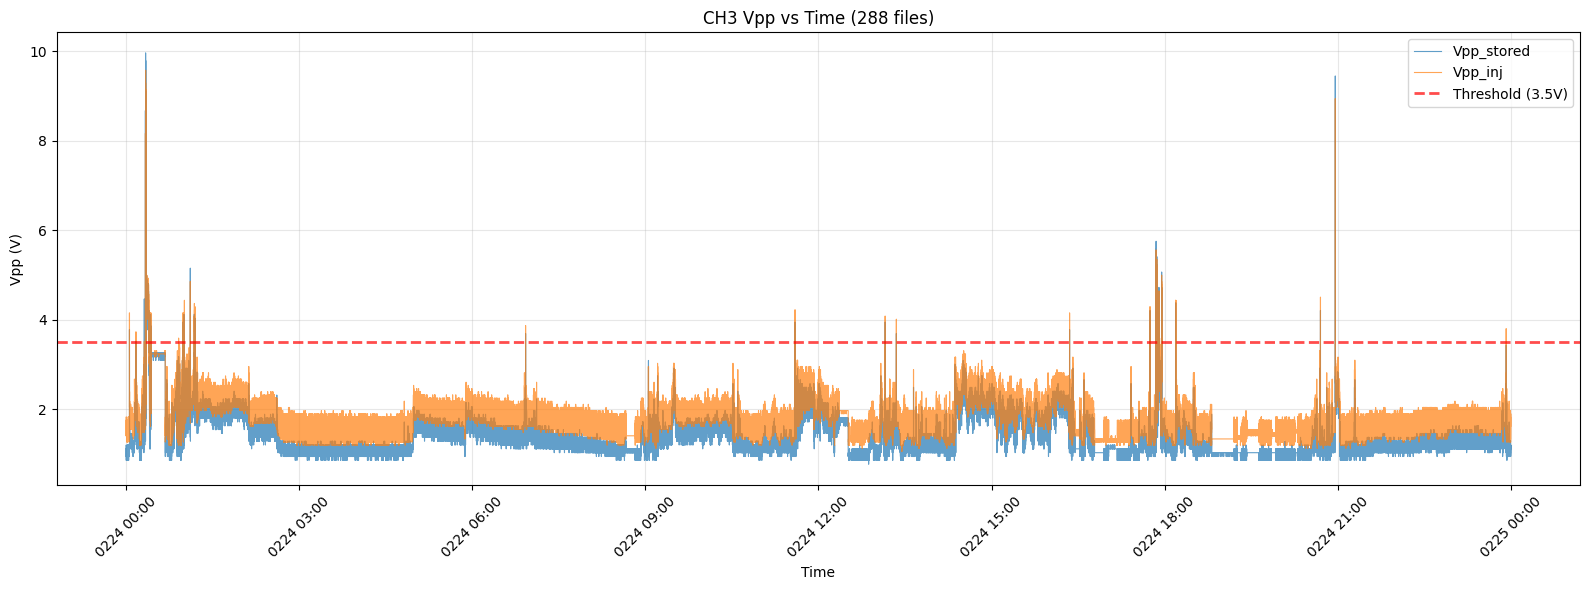


Found 221 STORED peaks
Found 241 INJ peaks

STORED peaks:
  1. 2026-02-24 00:03:27 → stored=3.7775V, inj=3.8005V
  2. 2026-02-24 00:10:12 → stored=3.5200V, inj=3.5190V
  3. 2026-02-24 00:18:52 → stored=4.4644V, inj=3.5190V
  4. 2026-02-24 00:20:02 → stored=8.6711V, inj=7.9529V
  5. 2026-02-24 00:20:10 → stored=9.1863V, inj=8.5159V
  6. 2026-02-24 00:20:14 → stored=9.7014V, inj=8.9382V
  7. 2026-02-24 00:20:15 → stored=9.9589V, inj=9.5013V
  8. 2026-02-24 00:20:17 → stored=3.8634V, inj=3.8709V
  9. 2026-02-24 00:20:21 → stored=9.7872V, inj=9.4309V
  10. 2026-02-24 00:20:22 → stored=9.7014V, inj=9.1494V
  11. 2026-02-24 00:20:23 → stored=7.1258V, inj=6.8268V
  12. 2026-02-24 00:20:26 → stored=8.9287V, inj=8.4456V
  13. 2026-02-24 00:20:27 → stored=8.6711V, inj=8.2344V
  14. 2026-02-24 00:20:31 → stored=7.3834V, inj=7.2491V
  15. 2026-02-24 00:20:33 → stored=8.4994V, inj=8.2344V
  16. 2026-02-24 00:20:34 → stored=9.1004V, inj=8.7271V
  17. 2026-02-24 00:20:35 → stored=8.8429V, inj=8.2344

In [3]:
# Batch process one single date (SELF-CONTAINED - no need to run Cell 1 first)
import math
import os
import re
import glob
import cv2
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from scipy.signal import find_peaks, peak_widths
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ===== PARAMETER DEFINITIONS =====
# Parameters (CHANGE)
video_folder = "/Volumes/D06V1/D06V1/OSC_Videos/2026ab/20260224/"
# max_files = 3  # Set to None to process all files, or set to a specific number for testing
max_files = None
peak_threshold = 3.5 #V for peak detection in Vpp
profile_threshold_stored = 1000
profile_threshold_inj = 1000

# Create output folder
folder_name = os.path.basename(video_folder.rstrip('/'))
output_folder = f"/Users/xylu/Desktop/Data/acoustic_vpp/{folder_name}"
os.makedirs(output_folder, exist_ok=True)

# Parameters (DO NOT CHANGE)
grid_height_px_stored = 3.4/5.56*400/10/1.05
grid_height_px_inj = 3.95/5.56*400/10
inj_time_px = 30
v_div = 2.0
fps = 20.0

# ===== FUNCTION DEFINITIONS (copied from Cell 1) =====
def extract_datetime_from_filename(filename):
    match = re.search(r"(\d{8})_(\d{6})", filename)
    if not match:
        return None
    date_part, time_part = match.groups()
    return datetime.strptime(date_part + time_part, "%Y%m%d%H%M%S")

def _vpp_from_mask(mask_part, threshold, volts_per_pixel):
    vertical_profile = np.sum(mask_part, axis=1)
    smooth_profile = gaussian_filter1d(vertical_profile.astype(float), sigma=2.0)
    above_threshold = smooth_profile > threshold
    if np.any(above_threshold):
        threshold_positions = np.where(above_threshold)[0]
        y_min = threshold_positions[0]
        y_max = threshold_positions[-1]
        peak_width_pixels = y_max - y_min
        return peak_width_pixels * volts_per_pixel
    return np.nan

def compute_vpp_series_for_file(file_path, v_div=2.0, fps=20.0, threshold_stored=1000, threshold_inj=1000, split_x=None, grid_height_px_stored=3.4/5.56*400/10/1.05, grid_height_px_inj=3.95/5.56*400/10):
    cap = cv2.VideoCapture(file_path)
    volts_per_pixel_stored = v_div / grid_height_px_stored
    volts_per_pixel_inj = v_div / grid_height_px_inj

    vpp_stored_series = []
    vpp_inj_series = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        height, width, _ = frame.shape
        roi = frame[int(height * 0.2):int(height * 0.8), int(width * 0.1):int(width * 0.9)]

        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

        mask1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
        mask2 = cv2.inRange(hsv, np.array([160, 100, 100]), np.array([180, 255, 255]))
        red_mask = cv2.bitwise_or(mask1, mask2)

        split_idx = max(0, min(int(split_x), red_mask.shape[1] - 1))

        # Part 1: x <= inj_time_px (STORED)
        red_mask_stored = red_mask[:, :split_idx + 1]
        # Part 2: x > inj_time_px (INJ)
        red_mask_inj = red_mask[:, split_idx + 1:]

        if red_mask_stored.shape[1] > 0:
            vpp_stored_series.append(_vpp_from_mask(red_mask_stored, threshold_stored, volts_per_pixel_stored))
        else:
            vpp_stored_series.append(np.nan)

        if red_mask_inj.shape[1] > 0:
            vpp_inj_series.append(_vpp_from_mask(red_mask_inj, threshold_inj, volts_per_pixel_inj))
        else:
            vpp_inj_series.append(np.nan)

    cap.release()

    time_series_sec = np.arange(len(vpp_stored_series)) / fps
    return time_series_sec, np.array(vpp_stored_series), np.array(vpp_inj_series)

print(f"Processing .mkv files in: {video_folder}")
print("="*60)

# Find all .mkv files
mkv_files = sorted(glob.glob(os.path.join(video_folder, "*.mkv")))
print(f"Found {len(mkv_files)} total video file(s)")

mkv_files_to_process = mkv_files if max_files is None else mkv_files[:max_files]
print(f"Processing {len(mkv_files_to_process)} file(s)")
print("="*60)

# Container for combined data
all_time_datetime = []
all_vpp_stored = []
all_vpp_inj = []
file_info = []

for file_idx, file_path in enumerate(mkv_files_to_process):
    basename = os.path.basename(file_path)
    print(f"\n[{file_idx + 1}/{len(mkv_files_to_process)}] {basename}")
    
    start_dt = extract_datetime_from_filename(basename)
    if start_dt is None:
        print(f"  ⚠ Skipped: Could not extract datetime")
        continue
    
    try:
        time_s, vpp_stored, vpp_inj = compute_vpp_series_for_file(
            file_path,
            v_div=v_div,
            fps=fps,
            threshold_stored=profile_threshold_stored,
            threshold_inj=profile_threshold_inj,
            split_x=inj_time_px,
            grid_height_px_stored=grid_height_px_stored,
            grid_height_px_inj=grid_height_px_inj,
        )
        
        time_datetime_data = np.array([start_dt + timedelta(seconds=t) for t in time_s])
        
        all_time_datetime.extend(time_datetime_data)
        all_vpp_stored.extend(vpp_stored)
        all_vpp_inj.extend(vpp_inj)
        
        df = pd.DataFrame({
            'time_datetime': time_datetime_data.astype(str),
            'time_seconds': time_s,
            'vpp_stored': vpp_stored,
            'vpp_inj': vpp_inj
        })
        
        csv_filename = basename.replace('.mkv', '_vpp.csv')
        df.to_csv(os.path.join(output_folder, csv_filename), index=False)
        
        vpp_stored_min, vpp_stored_max = np.nanmin(vpp_stored), np.nanmax(vpp_stored)
        vpp_inj_min, vpp_inj_max = np.nanmin(vpp_inj), np.nanmax(vpp_inj)
        print(f"  ✓ Vpp_stored: {vpp_stored_min:.3f} - {vpp_stored_max:.3f} V")
        print(f"  ✓ Vpp_inj: {vpp_inj_min:.3f} - {vpp_inj_max:.3f} V")
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)}")

all_time_datetime = np.array(all_time_datetime)
all_vpp_stored = np.array(all_vpp_stored)
all_vpp_inj = np.array(all_vpp_inj)

print("\n" + "="*60)
print(f"COMBINED: {len(all_vpp_stored)} samples")
print(f"Vpp_stored: {np.nanmin(all_vpp_stored):.3f} - {np.nanmax(all_vpp_stored):.3f} V")
print(f"Vpp_inj: {np.nanmin(all_vpp_inj):.3f} - {np.nanmax(all_vpp_inj):.3f} V")
print("="*60)

# Plot
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(all_time_datetime, all_vpp_stored, linewidth=0.8, label='Vpp_stored', alpha=0.7)
ax.plot(all_time_datetime, all_vpp_inj, linewidth=0.8, label='Vpp_inj', alpha=0.7)
ax.axhline(y=peak_threshold, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Threshold ({peak_threshold}V)')
ax.set_title(f"CH3 Vpp vs Time ({len(mkv_files_to_process)} files)")
ax.set_xlabel("Time")
ax.set_ylabel("Vpp (V)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Find peaks
vpp_peaks_stored, _ = find_peaks(all_vpp_stored, height=peak_threshold, distance=20)
vpp_peaks_inj, _ = find_peaks(all_vpp_inj, height=peak_threshold, distance=20)

print(f"\nFound {len(vpp_peaks_stored)} STORED peaks")
print(f"Found {len(vpp_peaks_inj)} INJ peaks")
print("="*60)

if len(vpp_peaks_stored) > 0:
    print("\nSTORED peaks:")
    for i, idx in enumerate(vpp_peaks_stored, 1):
        t = all_time_datetime[idx]
        print(f"  {i}. {t.strftime('%Y-%m-%d %H:%M:%S')} → stored={all_vpp_stored[idx]:.4f}V, inj={all_vpp_inj[idx]:.4f}V")

if len(vpp_peaks_inj) > 0:
    print("\nINJ peaks:")
    for i, idx in enumerate(vpp_peaks_inj, 1):
        t = all_time_datetime[idx]
        print(f"  {i}. {t.strftime('%Y-%m-%d %H:%M:%S')} → inj={all_vpp_inj[idx]:.4f}V, stored={all_vpp_stored[idx]:.4f}V")

print("\nBatch processing complete!")
print(f"Data saved to: {output_folder}")

Saving peak summaries and figures...


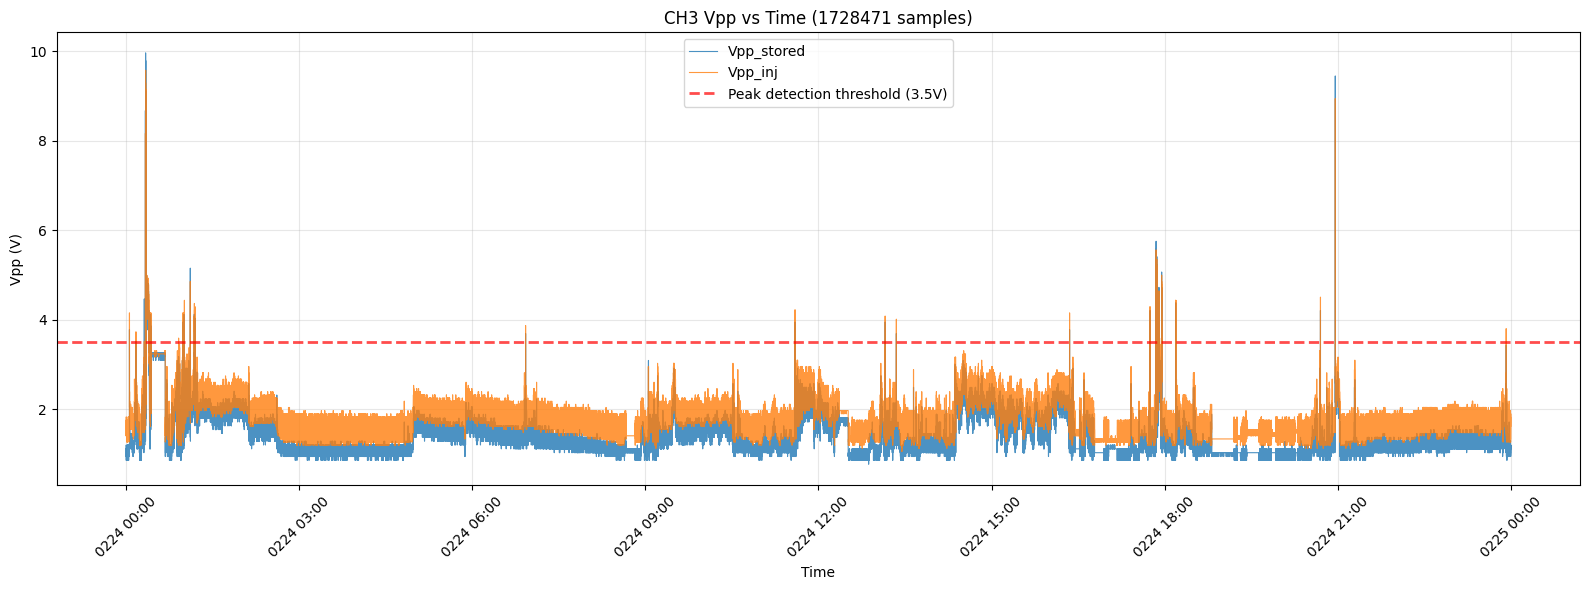

✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260224_peak_summary_plot.png

                        Stored Peaks                        
------------------------------------------------------------
  Peak 1: 2026-02-24 00:03:27 → stored=3.7775V, inj=3.8005V
  Peak 2: 2026-02-24 00:10:12 → stored=3.5200V, inj=3.5190V
  Peak 3: 2026-02-24 00:18:52 → stored=4.4644V, inj=3.5190V
  Peak 4: 2026-02-24 00:20:02 → stored=8.6711V, inj=7.9529V
  Peak 5: 2026-02-24 00:20:10 → stored=9.1863V, inj=8.5159V
  Peak 6: 2026-02-24 00:20:14 → stored=9.7014V, inj=8.9382V
  Peak 7: 2026-02-24 00:20:15 → stored=9.9589V, inj=9.5013V
  Peak 8: 2026-02-24 00:20:17 → stored=3.8634V, inj=3.8709V
  Peak 9: 2026-02-24 00:20:21 → stored=9.7872V, inj=9.4309V
  Peak 10: 2026-02-24 00:20:22 → stored=9.7014V, inj=9.1494V
  Peak 11: 2026-02-24 00:20:23 → stored=7.1258V, inj=6.8268V
  Peak 12: 2026-02-24 00:20:26 → stored=8.9287V, inj=8.4456V
  Peak 13: 2026-02-24 00:20:27 → stored=8.6711V

In [5]:
# Save peak summary and figures for both STORED and INJ peaks
# Uses vpp_peaks_stored and vpp_peaks_inj computed from Cell 4

print("Saving peak summaries and figures...")
print("="*60)

# Get folder name for output filenames
folder_name = os.path.basename(output_folder.rstrip('/'))

# Create summary folder
summary_folder = os.path.abspath(os.path.join(output_folder, '../summary/'))
os.makedirs(summary_folder, exist_ok=True)

# Create summary figure with BOTH signals
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(all_time_datetime, all_vpp_stored, linewidth=0.8, label='Vpp_stored', alpha=0.8)
ax.plot(all_time_datetime, all_vpp_inj, linewidth=0.8, label='Vpp_inj', alpha=0.8)
ax.axhline(y=peak_threshold, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Peak detection threshold ({peak_threshold}V)')

ax.set_title(f"CH3 Vpp vs Time ({len(all_vpp_stored)} samples)")
ax.set_xlabel("Time")
ax.set_ylabel("Vpp (V)")
ax.legend()
ax.grid(True, alpha=0.3)

# Format x-axis as MMDD HH:MM
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plot_path = os.path.join(summary_folder, f"{folder_name}_peak_summary_plot.png")
plt.savefig(plot_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ Peak summary plot saved to: {plot_path}")

# Save STORED peaks to CSV
print(f"\n{'Stored Peaks':^60}")
print("-"*60)
if len(vpp_peaks_stored) == 0:
    print("No STORED peaks found!")
else:
    stored_peak_data = []
    for peak_idx, sample_idx in enumerate(vpp_peaks_stored):
        peak_time = all_time_datetime[sample_idx]
        vpp_stored_val = all_vpp_stored[sample_idx]
        vpp_inj_val = all_vpp_inj[sample_idx]
        
        stored_peak_data.append({
            'peak_number': peak_idx + 1,
            'sample_idx': int(sample_idx),
            'time_datetime': peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3],
            'vpp_stored_volts': float(vpp_stored_val),
            'vpp_inj_volts': float(vpp_inj_val)
        })
        print(f"  Peak {peak_idx + 1}: {peak_time.strftime('%Y-%m-%d %H:%M:%S')} → "
              f"stored={vpp_stored_val:.4f}V, inj={vpp_inj_val:.4f}V")
    
    stored_df = pd.DataFrame(stored_peak_data)
    stored_csv_path = os.path.join(summary_folder, f"{folder_name}_peaks_stored.csv")
    stored_df.to_csv(stored_csv_path, index=False)
    print(f"\n✓ Stored peaks saved to: {stored_csv_path}")

# Save INJ peaks to CSV
print(f"\n{'Inj Peaks':^60}")
print("-"*60)
if len(vpp_peaks_inj) == 0:
    print("No INJ peaks found!")
else:
    inj_peak_data = []
    for peak_idx, sample_idx in enumerate(vpp_peaks_inj):
        peak_time = all_time_datetime[sample_idx]
        vpp_stored_val = all_vpp_stored[sample_idx]
        vpp_inj_val = all_vpp_inj[sample_idx]
        
        inj_peak_data.append({
            'peak_number': peak_idx + 1,
            'sample_idx': int(sample_idx),
            'time_datetime': peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3],
            'vpp_inj_volts': float(vpp_inj_val),
            'vpp_stored_volts': float(vpp_stored_val)
        })
        print(f"  Peak {peak_idx + 1}: {peak_time.strftime('%Y-%m-%d %H:%M:%S')} → "
              f"inj={vpp_inj_val:.4f}V, stored={vpp_stored_val:.4f}V")
    
    inj_df = pd.DataFrame(inj_peak_data)
    inj_csv_path = os.path.join(summary_folder, f"{folder_name}_peaks_inj.csv")
    inj_df.to_csv(inj_csv_path, index=False)
    print(f"\n✓ Inj peaks saved to: {inj_csv_path}")

print("\n" + "="*60)
print("Save complete!")
print(f"Total STORED peaks: {len(vpp_peaks_stored)}")
print(f"Total INJ peaks: {len(vpp_peaks_inj)}")
print(f"Summary folder: {summary_folder}")

Saving peak summaries and figures...


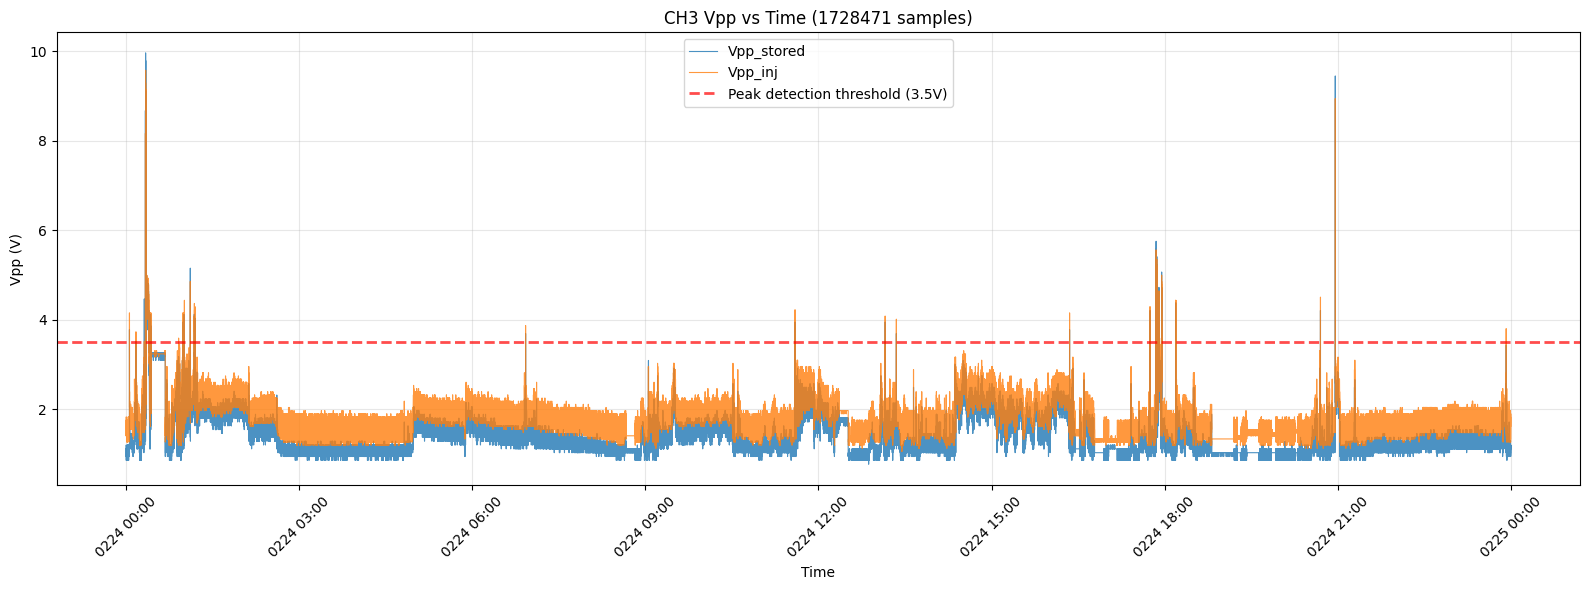

✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260224_peak_summary_plot.png

                        Stored Peaks                        
------------------------------------------------------------
  Peak 1: 2026-02-24 00:03:27 → stored=3.7775V, inj=3.8005V
  Peak 2: 2026-02-24 00:10:12 → stored=3.5200V, inj=3.5190V
  Peak 3: 2026-02-24 00:18:52 → stored=4.4644V, inj=3.5190V
  Peak 4: 2026-02-24 00:20:02 → stored=8.6711V, inj=7.9529V
  Peak 5: 2026-02-24 00:20:10 → stored=9.1863V, inj=8.5159V
  Peak 6: 2026-02-24 00:20:14 → stored=9.7014V, inj=8.9382V
  Peak 7: 2026-02-24 00:20:15 → stored=9.9589V, inj=9.5013V
  Peak 8: 2026-02-24 00:20:17 → stored=3.8634V, inj=3.8709V
  Peak 9: 2026-02-24 00:20:21 → stored=9.7872V, inj=9.4309V
  Peak 10: 2026-02-24 00:20:22 → stored=9.7014V, inj=9.1494V
  Peak 11: 2026-02-24 00:20:23 → stored=7.1258V, inj=6.8268V
  Peak 12: 2026-02-24 00:20:26 → stored=8.9287V, inj=8.4456V
  Peak 13: 2026-02-24 00:20:27 → stored=8.6711V

In [7]:
# Save peak summary and figures for both STORED and INJ peaks
# Uses vpp_peaks_stored and vpp_peaks_inj computed from Cell 4

print("Saving peak summaries and figures...")
print("="*60)

# Get folder name for output filenames
folder_name = os.path.basename(output_folder.rstrip('/'))

# Create summary folder
summary_folder = os.path.abspath(os.path.join(output_folder, '../summary/'))
os.makedirs(summary_folder, exist_ok=True)

# Create summary figure with BOTH signals
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(all_time_datetime, all_vpp_stored, linewidth=0.8, label='Vpp_stored', alpha=0.8)
ax.plot(all_time_datetime, all_vpp_inj, linewidth=0.8, label='Vpp_inj', alpha=0.8)
ax.axhline(y=peak_threshold, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Peak detection threshold ({peak_threshold}V)')

ax.set_title(f"CH3 Vpp vs Time ({len(all_vpp_stored)} samples)")
ax.set_xlabel("Time")
ax.set_ylabel("Vpp (V)")
ax.legend()
ax.grid(True, alpha=0.3)

# Format x-axis as MMDD HH:MM
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plot_path = os.path.join(summary_folder, f"{folder_name}_peak_summary_plot.png")
plt.savefig(plot_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ Peak summary plot saved to: {plot_path}")

# Save STORED peaks to CSV
print(f"\n{'Stored Peaks':^60}")
print("-"*60)
if len(vpp_peaks_stored) == 0:
    print("No STORED peaks found!")
else:
    stored_peak_data = []
    for peak_idx, sample_idx in enumerate(vpp_peaks_stored):
        peak_time = all_time_datetime[sample_idx]
        vpp_stored_val = all_vpp_stored[sample_idx]
        vpp_inj_val = all_vpp_inj[sample_idx]
        
        stored_peak_data.append({
            'peak_number': peak_idx + 1,
            'sample_idx': int(sample_idx),
            'time_datetime': peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3],
            'vpp_stored_volts': float(vpp_stored_val),
            'vpp_inj_volts': float(vpp_inj_val)
        })
        print(f"  Peak {peak_idx + 1}: {peak_time.strftime('%Y-%m-%d %H:%M:%S')} → "
              f"stored={vpp_stored_val:.4f}V, inj={vpp_inj_val:.4f}V")
    
    stored_df = pd.DataFrame(stored_peak_data)
    stored_csv_path = os.path.join(summary_folder, f"{folder_name}_peaks_stored.csv")
    stored_df.to_csv(stored_csv_path, index=False)
    print(f"\n✓ Stored peaks saved to: {stored_csv_path}")

# Save INJ peaks to CSV
print(f"\n{'Inj Peaks':^60}")
print("-"*60)
if len(vpp_peaks_inj) == 0:
    print("No INJ peaks found!")
else:
    inj_peak_data = []
    for peak_idx, sample_idx in enumerate(vpp_peaks_inj):
        peak_time = all_time_datetime[sample_idx]
        vpp_stored_val = all_vpp_stored[sample_idx]
        vpp_inj_val = all_vpp_inj[sample_idx]
        
        inj_peak_data.append({
            'peak_number': peak_idx + 1,
            'sample_idx': int(sample_idx),
            'time_datetime': peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3],
            'vpp_inj_volts': float(vpp_inj_val),
            'vpp_stored_volts': float(vpp_stored_val)
        })
        print(f"  Peak {peak_idx + 1}: {peak_time.strftime('%Y-%m-%d %H:%M:%S')} → "
              f"inj={vpp_inj_val:.4f}V, stored={vpp_stored_val:.4f}V")
    
    inj_df = pd.DataFrame(inj_peak_data)
    inj_csv_path = os.path.join(summary_folder, f"{folder_name}_peaks_inj.csv")
    inj_df.to_csv(inj_csv_path, index=False)
    print(f"\n✓ Inj peaks saved to: {inj_csv_path}")

print("\n" + "="*60)
print("Save complete!")
print(f"Total STORED peaks: {len(vpp_peaks_stored)}")
print(f"Total INJ peaks: {len(vpp_peaks_inj)}")
print(f"Summary folder: {summary_folder}")

In [ ]:
# Function definitions and imports for batch processing all folders
import os
import re
import cv2
import numpy as np
from datetime import datetime, timedelta
from scipy.signal import find_peaks, peak_widths
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import pandas as pd

# Parameters (CHANGE)
parent_folder = "/Volumes/D06V1/D06V1/OSC_Videos/2026ab/"
# parent_folder = "/Volumes/Untitled/"
peak_threshold = 3.5  # V, for peak detection in Vpp signal
profile_threshold_stored = 1000  # Threshold for stored region
profile_threshold_inj = 1000     # Threshold for inj region
# max_files = 3  # Set to a number to limit files per folder, or None to process all
max_files = None  # Uncomment to process all files

# Parameters (DO NOT CHANGE)
grid_height_px_stored = 3.4/5.56*400/10/1.05  # stored region (distorted)
grid_height_px_inj = 3.95/5.56*400/10         # inj region
inj_time_px = 30
v_div = 2.0
fps = 20.0

def extract_datetime_from_filename(filename):
    """Extract YYYYMMDD_HHMMSS from filename."""
    match = re.search(r"(\d{8})_(\d{6})", filename)
    if not match:
        return None
    date_part, time_part = match.groups()
    return datetime.strptime(date_part + time_part, "%Y%m%d%H%M%S")

def _vpp_from_mask(mask_part, threshold, volts_per_pixel):
    """Compute Vpp from mask using profile + threshold method."""
    vertical_profile = np.sum(mask_part, axis=1)
    smooth_profile = gaussian_filter1d(vertical_profile.astype(float), sigma=2.0)
    above_threshold = smooth_profile > threshold
    if np.any(above_threshold):
        threshold_positions = np.where(above_threshold)[0]
        y_min = threshold_positions[0]
        y_max = threshold_positions[-1]
        peak_width_pixels = y_max - y_min
        return peak_width_pixels * volts_per_pixel
    return np.nan

def compute_vpp_series_for_file(file_path, v_div=2.0, fps=20.0, threshold_stored=1000, threshold_inj=1000, split_x=None, grid_height_px_stored=3.4/5.56*400/10/1.05, grid_height_px_inj=3.95/5.56*400/10):
    """Compute Vpp for CH3 (red trace) per frame for both stored and inj regions."""
    cap = cv2.VideoCapture(file_path)
    volts_per_pixel_stored = v_div / grid_height_px_stored
    volts_per_pixel_inj = v_div / grid_height_px_inj

    vpp_stored_series = []
    vpp_inj_series = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        height, width, _ = frame.shape
        roi = frame[int(height * 0.2):int(height * 0.8), int(width * 0.1):int(width * 0.9)]

        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
        mask1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
        mask2 = cv2.inRange(hsv, np.array([160, 100, 100]), np.array([180, 255, 255]))
        red_mask = cv2.bitwise_or(mask1, mask2)

        split_idx = max(0, min(int(split_x), red_mask.shape[1] - 1))
        red_mask_stored = red_mask[:, :split_idx + 1]
        red_mask_inj = red_mask[:, split_idx + 1:]

        if red_mask_stored.shape[1] > 0:
            vpp_stored_series.append(_vpp_from_mask(red_mask_stored, threshold_stored, volts_per_pixel_stored))
        else:
            vpp_stored_series.append(np.nan)

        if red_mask_inj.shape[1] > 0:
            vpp_inj_series.append(_vpp_from_mask(red_mask_inj, threshold_inj, volts_per_pixel_inj))
        else:
            vpp_inj_series.append(np.nan)

    cap.release()
    time_series_sec = np.arange(len(vpp_stored_series)) / fps
    return time_series_sec, np.array(vpp_stored_series), np.array(vpp_inj_series)

In [ ]:
# Get all subfolders in parent directory
subfolders = sorted([f.path for f in os.scandir(parent_folder) if f.is_dir()])
print(f"Found {len(subfolders)} folder(s) in: {parent_folder}")
print("="*60)

for folder_idx, video_folder in enumerate(subfolders):
    folder_name = os.path.basename(video_folder.rstrip('/'))
    print(f"\n{'='*60}")
    print(f"[{folder_idx + 1}/{len(subfolders)}] Processing folder: {folder_name}")
    print("="*60)
    
    # Find all .mkv files - try direct folder first
    mkv_files = sorted(glob.glob(os.path.join(video_folder, "*.mkv")))
    
    # If no files found, try RecData/0014 subdirectory
    if len(mkv_files) == 0:
        nested_folder = os.path.join(video_folder, "RecData", "0014")
        if os.path.isdir(nested_folder):
            mkv_files = sorted(glob.glob(os.path.join(nested_folder, "*.mkv")))
            if len(mkv_files) > 0:
                print(f"  → Found files in RecData/0014 subdirectory")
                video_folder = nested_folder
    
    print(f"Found {len(mkv_files)} total video file(s)")
    
    if len(mkv_files) == 0:
        print("  ⚠ No .mkv files found, skipping folder")
        continue
    
    # Create output folder based on video folder name
    output_folder = f"/Users/xylu/Desktop/Data/acoustic_vpp/{folder_name}"
    os.makedirs(output_folder, exist_ok=True)
    
    # Process files
    if max_files is None:
        mkv_files_to_process = mkv_files
        print(f"Processing all {len(mkv_files_to_process)} file(s)")
    else:
        mkv_files_to_process = mkv_files[:max_files]
        print(f"Processing {len(mkv_files_to_process)} file(s) (limited by max_files={max_files})")
    print("="*60)
    
    # Container for combined data
    all_time_datetime = []
    all_vpp_stored = []
    all_vpp_inj = []
    file_info = []
    
    for file_idx, file_path in enumerate(mkv_files_to_process):
        basename = os.path.basename(file_path)
        print(f"\n[{file_idx + 1}/{len(mkv_files_to_process)}] {basename}")
        
        # Extract start time
        start_dt = extract_datetime_from_filename(basename)
        if start_dt is None:
            print(f"  ⚠ Skipped: Could not extract datetime")
            continue
        
        # Compute Vpp series for both regions
        try:
            time_s, vpp_stored, vpp_inj = compute_vpp_series_for_file(
                file_path,
                v_div=v_div,
                fps=fps,
                threshold_stored=profile_threshold_stored,
                threshold_inj=profile_threshold_inj,
                split_x=inj_time_px,
                grid_height_px_stored=grid_height_px_stored,
                grid_height_px_inj=grid_height_px_inj,
            )
            
            # Convert time to datetime
            time_datetime_data = np.array([start_dt + timedelta(seconds=t) for t in time_s])
            
            # Accumulate data
            all_time_datetime.extend(time_datetime_data)
            all_vpp_stored.extend(vpp_stored)
            all_vpp_inj.extend(vpp_inj)
            
            # Create DataFrame for individual file
            df = pd.DataFrame({
                'time_datetime': time_datetime_data.astype(str),
                'time_seconds': time_s,
                'vpp_stored': vpp_stored,
                'vpp_inj': vpp_inj
            })
            
            # Save individual CSV
            csv_filename = basename.replace('.mkv', '_vpp.csv')
            csv_filepath = os.path.join(output_folder, csv_filename)
            df.to_csv(csv_filepath, index=False)
            
            vpp_stored_min, vpp_stored_max = np.nanmin(vpp_stored), np.nanmax(vpp_stored)
            vpp_inj_min, vpp_inj_max = np.nanmin(vpp_inj), np.nanmax(vpp_inj)
            print(f"  ✓ Vpp_stored: {vpp_stored_min:.3f} - {vpp_stored_max:.3f} V")
            print(f"  ✓ Vpp_inj: {vpp_inj_min:.3f} - {vpp_inj_max:.3f} V")
            file_info.append((basename, start_dt, vpp_stored_min, vpp_stored_max, vpp_inj_min, vpp_inj_max))
            
        except Exception as e:
            print(f"  ✗ Error: {str(e)}")
    
    # Convert to arrays
    all_time_datetime = np.array(all_time_datetime)
    all_vpp_stored = np.array(all_vpp_stored)
    all_vpp_inj = np.array(all_vpp_inj)
    
    print("\n" + "="*60)
    print(f"COMBINED DATA: {len(all_vpp_stored)} samples")
    if len(all_vpp_stored) > 0:
        print(f"Vpp_stored: {np.nanmin(all_vpp_stored):.3f} - {np.nanmax(all_vpp_stored):.3f} V")
        print(f"Vpp_inj: {np.nanmin(all_vpp_inj):.3f} - {np.nanmax(all_vpp_inj):.3f} V")
        print(f"Time span: {all_time_datetime[0]} to {all_time_datetime[-1]}")
    print("="*60)
    
    # Plot combined Vpp vs time
    if len(all_vpp_stored) > 0:
        fig, ax = plt.subplots(figsize=(16, 6))
        ax.plot(all_time_datetime, all_vpp_stored, linewidth=0.8, label='Vpp_stored', alpha=0.8)
        ax.plot(all_time_datetime, all_vpp_inj, linewidth=0.8, label='Vpp_inj', alpha=0.8)
        ax.axhline(y=peak_threshold, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Peak detection threshold ({peak_threshold}V)')
        ax.set_title(f"CH3 Vpp vs Time - {folder_name} ({len(mkv_files_to_process)} files)")
        ax.set_xlabel("Time")
        ax.set_ylabel("Vpp (V)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Find peaks in both signals
        vpp_peaks_stored, _ = find_peaks(all_vpp_stored, height=peak_threshold, distance=20)
        vpp_peaks_inj, _ = find_peaks(all_vpp_inj, height=peak_threshold, distance=20)
        print(f"\nFound {len(vpp_peaks_stored)} STORED peaks with Vpp > {peak_threshold} V")
        print(f"Found {len(vpp_peaks_inj)} INJ peaks with Vpp > {peak_threshold} V")
        print("="*60)
        
        # Save peak summaries and figure
        summary_folder = os.path.abspath(os.path.join(output_folder, '../summary/'))
        os.makedirs(summary_folder, exist_ok=True)
        
        # Create summary figure with both signals
        fig, ax = plt.subplots(figsize=(16, 6))
        ax.plot(all_time_datetime, all_vpp_stored, linewidth=0.8, label='Vpp_stored', alpha=0.8)
        ax.plot(all_time_datetime, all_vpp_inj, linewidth=0.8, label='Vpp_inj', alpha=0.8)
        ax.axhline(y=peak_threshold, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Peak detection threshold ({peak_threshold}V)')
        ax.set_title(f"CH3 Vpp vs Time - {folder_name} ({len(all_vpp_stored)} samples)")
        ax.set_xlabel("Time")
        ax.set_ylabel("Vpp (V)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plot_path = os.path.join(summary_folder, f"{folder_name}_peak_summary_plot.png")
        plt.savefig(plot_path, dpi=100, bbox_inches='tight')
        plt.show()
        print(f"✓ Peak summary plot saved to: {plot_path}")
        
        # Save STORED peaks
        if len(vpp_peaks_stored) > 0:
            stored_peak_data = []
            for peak_idx, sample_idx in enumerate(vpp_peaks_stored):
                peak_time = all_time_datetime[sample_idx]
                vpp_stored_val = all_vpp_stored[sample_idx]
                vpp_inj_val = all_vpp_inj[sample_idx]
                stored_peak_data.append({
                    'peak_number': peak_idx + 1,
                    'sample_idx': int(sample_idx),
                    'time_datetime': peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3],
                    'vpp_stored_volts': float(vpp_stored_val),
                    'vpp_inj_volts': float(vpp_inj_val)
                })
            stored_df = pd.DataFrame(stored_peak_data)
            stored_csv_path = os.path.join(summary_folder, f"{folder_name}_peaks_stored.csv")
            stored_df.to_csv(stored_csv_path, index=False)
            print(f"✓ Stored peaks saved to: {stored_csv_path}")
        
        # Save INJ peaks
        if len(vpp_peaks_inj) > 0:
            inj_peak_data = []
            for peak_idx, sample_idx in enumerate(vpp_peaks_inj):
                peak_time = all_time_datetime[sample_idx]
                vpp_stored_val = all_vpp_stored[sample_idx]
                vpp_inj_val = all_vpp_inj[sample_idx]
                inj_peak_data.append({
                    'peak_number': peak_idx + 1,
                    'sample_idx': int(sample_idx),
                    'time_datetime': peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3],
                    'vpp_inj_volts': float(vpp_inj_val),
                    'vpp_stored_volts': float(vpp_stored_val)
                })
            inj_df = pd.DataFrame(inj_peak_data)
            inj_csv_path = os.path.join(summary_folder, f"{folder_name}_peaks_inj.csv")
            inj_df.to_csv(inj_csv_path, index=False)
            print(f"✓ Inj peaks saved to: {inj_csv_path}")
    
    print(f"\n✓ Folder '{folder_name}' complete! Data saved to: {output_folder}")

print("\n" + "="*60)
print("ALL FOLDERS PROCESSED!")
print("="*60)
                    'vpp_stored_volts': float(vpp_stored_val)